# Лабораторная работа №2
## Разведочный анализ данных (EDA)

**Выполнил:** _Машканов Михаил Вячеславович_
**Группа:** _14_

**Среда выполнения:** Anaconda Jupyter Notebook, окружение conda `lab1_terminal`.

**Цель работы:** изучение основных методов разведочного анализа данных, выявление скрытых
закономерностей, поиск аномалий, визуализация распределений признаков и подготовка данных
к последующему моделированию.

---
# Часть 1. Наборы данных

Выбраны два набора данных из репозитория UCI, отличающиеся от использованных в ЛР №1 (Iris, Titanic):

| № | Набор данных | Файл | Характер признаков |
|---|---|---|---|
| 1 | [Wine Quality](https://archive.ics.uci.edu/dataset/186/wine+quality) (красные вина) | `data/winequality-red.csv` | все признаки числовые |
| 2 | [Adult (Census Income)](https://archive.ics.uci.edu/dataset/2/adult) | `data/adult.csv` | числовые и категориальные признаки, есть пропуски |

In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

%matplotlib inline
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 140)

DATA_DIR = Path("data")


def iqr_outliers(df: pd.DataFrame) -> pd.DataFrame:
    # Число выбросов по правилу 1.5*IQR (то же правило, по которому boxplot рисует «усы»)
    q1, q3 = df.quantile(0.25), df.quantile(0.75)
    iqr = q3 - q1
    mask = (df < q1 - 1.5 * iqr) | (df > q3 + 1.5 * iqr)
    return pd.DataFrame({"выбросов": mask.sum(), "доля, %": (mask.mean() * 100).round(2)}) \
             .sort_values("выбросов", ascending=False)

---
# Часть 2.1. Набор данных №1 — Wine Quality

Физико-химические показатели 1599 образцов красного вина и экспертная оценка качества `quality`.

## 1. Первичный аудит и структура данных

In [2]:
wine = pd.read_csv(DATA_DIR / "winequality-red.csv", sep=";")
wine.columns = wine.columns.str.replace(" ", "_")   # пробелы в именах столбцов → «_»

display(wine.head(10))
display(wine.tail(10))

,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5


,fixed_acidity,volatile_acidity,citric_acid,residual_sugar,chlorides,free_sulfur_dioxide,total_sulfur_dioxide,density,pH,sulphates,alcohol,quality
1589,6.6,0.725,0.20,7.8,0.073,29.0,79.0,0.99770,3.29,0.54,9.2,5
1590,6.3,0.550,0.15,1.8,0.077,26.0,35.0,0.99314,3.32,0.82,11.6,6
1591,5.4,0.740,0.09,1.7,0.089,16.0,26.0,0.99402,3.67,0.56,11.6,6
1592,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1593,6.8,0.620,0.08,1.9,0.068,28.0,38.0,0.99651,3.42,0.82,9.5,6
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5
1598,6.0,0.310,0.47,3.6,0.067,18.0,42.0,0.99549,3.39,0.66,11.0,6


In [3]:
print("Размерность (строк, столбцов):", wine.shape)
print()
wine.info()

Размерность (строк, столбцов): (1599, 12)

<class 'pandas.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed_acidity         1599 non-null   float64
 1   volatile_acidity      1599 non-null   float64
 2   citric_acid           1599 non-null   float64
 3   residual_sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free_sulfur_dioxide   1599 non-null   float64
 6   total_sulfur_dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


Все 12 столбцов числовые, типы соответствуют значениям: 11 физико-химических показателей —
вещественные числа (`float64`), оценка `quality` — целое число (`int64`). При этом `quality`
принимает всего 6 значений (3…8), то есть по смыслу это порядковый категориальный признак.

## 2. Статистический анализ и очистка данных

In [4]:
wine.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed_acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile_acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric_acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual_sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free_sulfur_dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total_sulfur_dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


In [5]:
# quality — дискретный признак: число уникальных значений и мода
print("Уникальных значений quality:", wine["quality"].nunique())
print("Мода quality:", wine["quality"].mode()[0])
print(wine["quality"].value_counts().sort_index().to_string())

Уникальных значений quality: 6
Мода quality: 5
quality
3     10
4     53
5    681
6    638
7    199
8     18


Почти у всех признаков среднее больше медианы (`50%`), а максимум намного превышает 75-й
перцентиль — распределения скошены вправо, сильнее всего у `residual_sugar`, `chlorides`
и `sulphates`. Признаки измерены в разных масштабах (СКО `density` ≈ 0.002, СКО
`total_sulfur_dioxide` ≈ 33). По `quality` преобладают оценки 5 и 6 (мода — 5),
крайние оценки 3 и 8 встречаются редко.

In [6]:
print("Пропуски по столбцам:")
print(wine.isna().sum().to_string())

Пропуски по столбцам:
fixed_acidity           0
volatile_acidity        0
citric_acid             0
residual_sugar          0
chlorides               0
free_sulfur_dioxide     0
total_sulfur_dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0


Пропусков в наборе нет, поэтому обработка не требуется (обработка пропусков показана
на втором наборе данных).

In [7]:
print("Дубликатов:", wine.duplicated().sum())
wine = wine.drop_duplicates().reset_index(drop=True)
print("Размерность после удаления дубликатов:", wine.shape)

Дубликатов: 240
Размерность после удаления дубликатов: (1359, 12)


Найдено 240 полностью повторяющихся строк (15 % данных) — они удалены, дальше анализ
выполняется на 1359 строках.

## 3. Визуальный анализ распределений и поиск аномалий

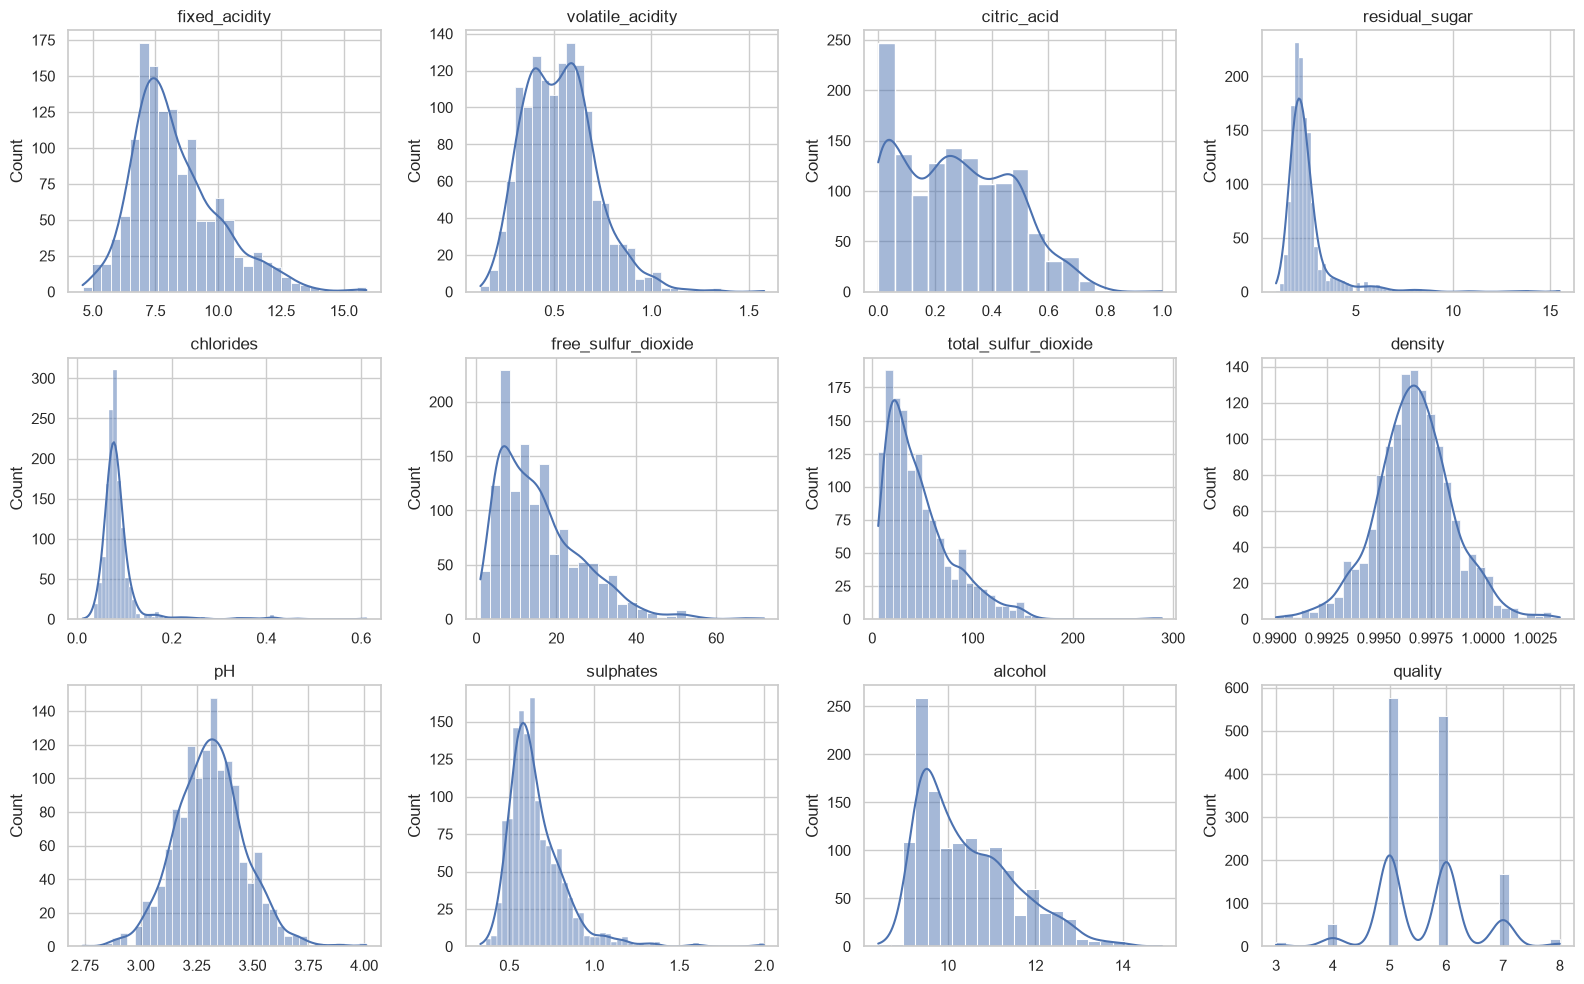

In [8]:
fig, axes = plt.subplots(3, 4, figsize=(16, 10))
for ax, col in zip(axes.flat, wine.columns):
    sns.histplot(wine[col], kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.tight_layout()
plt.show()

Симметричные, близкие к нормальному распределения имеют `density` и `pH`. Большинство
остальных признаков скошены вправо, а у `residual_sugar`, `chlorides` и `sulphates` основная масса
значений сосредоточена в узком диапазоне и есть длинный правый «хвост» редких больших значений.
`quality` — дискретный признак с пиками на 5 и 6.

**Один признак — три типа графиков** (содержание алкоголя `alcohol`):

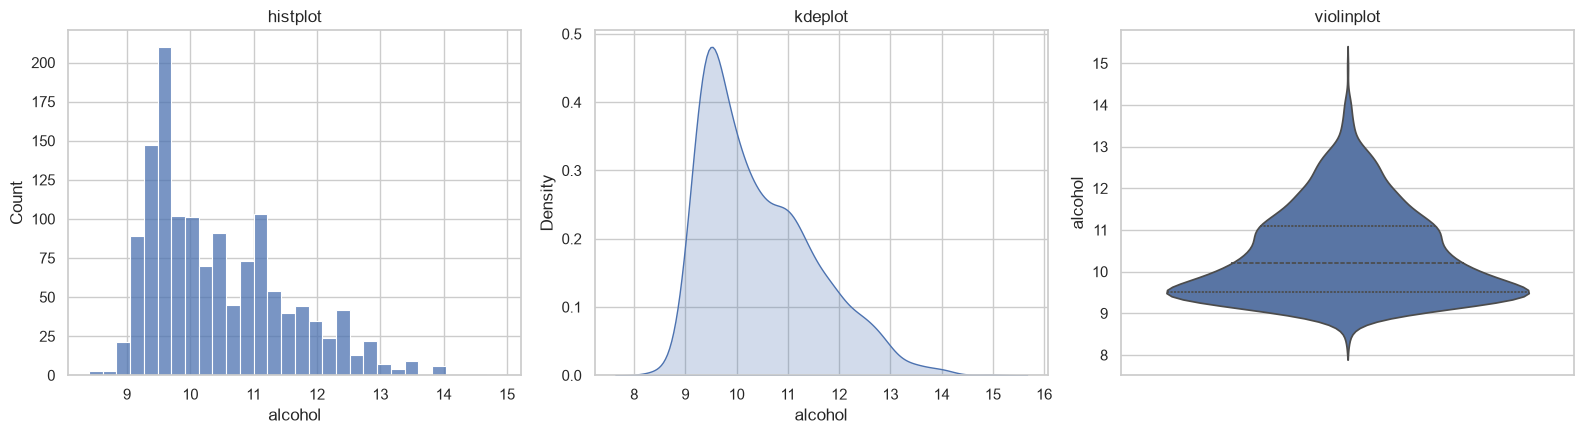

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(wine["alcohol"], bins=30, ax=axes[0])
axes[0].set_title("histplot")
sns.kdeplot(wine["alcohol"], fill=True, ax=axes[1])
axes[1].set_title("kdeplot")
sns.violinplot(y=wine["alcohol"], inner="quartile", ax=axes[2])
axes[2].set_title("violinplot")
fig.tight_layout()
plt.show()

Все три графика показывают одно и то же распределение: пик около 9.5 %, правая асимметрия
и редкие значения до 14–15 %. Гистограмма показывает «сырые» частоты (её вид зависит
от числа интервалов), график плотности даёт сглаженную форму, а скрипичная диаграмма
дополнительно отмечает медиану и квартили (пунктир).

**Диаграммы размаха (boxplot)** для поиска выбросов:

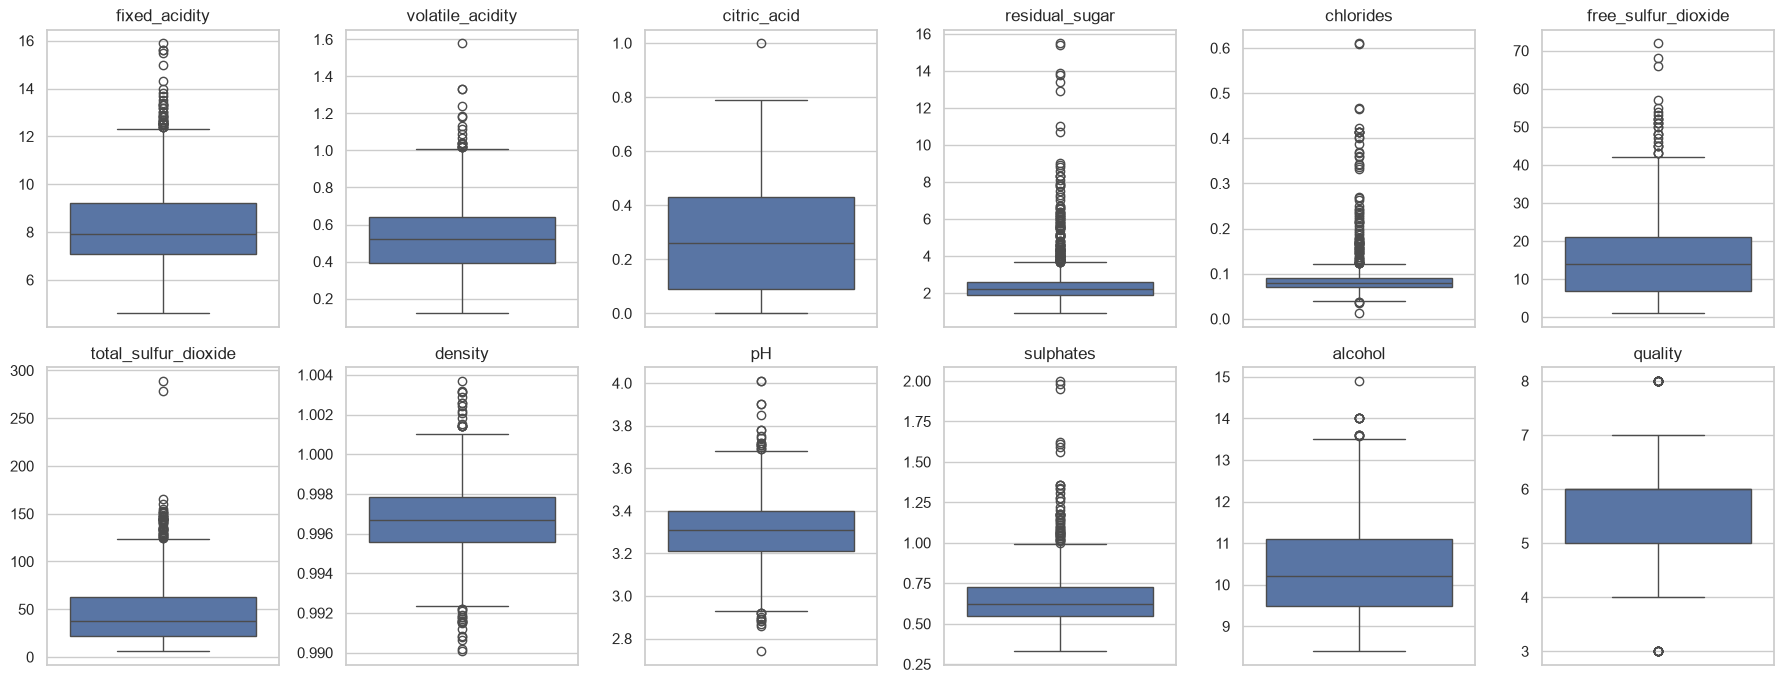

,выбросов,"доля, %"
residual_sugar,126,9.27
chlorides,87,6.40
sulphates,55,4.05
total_sulfur_dioxide,45,3.31
fixed_acidity,41,3.02
density,35,2.58
pH,28,2.06
quality,27,1.99
free_sulfur_dioxide,26,1.91
volatile_acidity,19,1.40


In [10]:
fig, axes = plt.subplots(2, 6, figsize=(18, 7))
for ax, col in zip(axes.flat, wine.columns):
    sns.boxplot(y=wine[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")
fig.tight_layout()
plt.show()

iqr_outliers(wine)

Больше всего выбросов у `residual_sugar` (≈ 9 %) и `chlorides` (≈ 6 %), заметное количество —
у `sulphates`, `total_sulfur_dioxide` и `fixed_acidity`; почти все выбросы верхние.
У `citric_acid` и `alcohol` выбросов почти нет. Значения физически правдоподобны (это редкие
вина, а не ошибки ввода), поэтому удалять их не обязательно.

## 4. Корреляционный анализ и зависимости

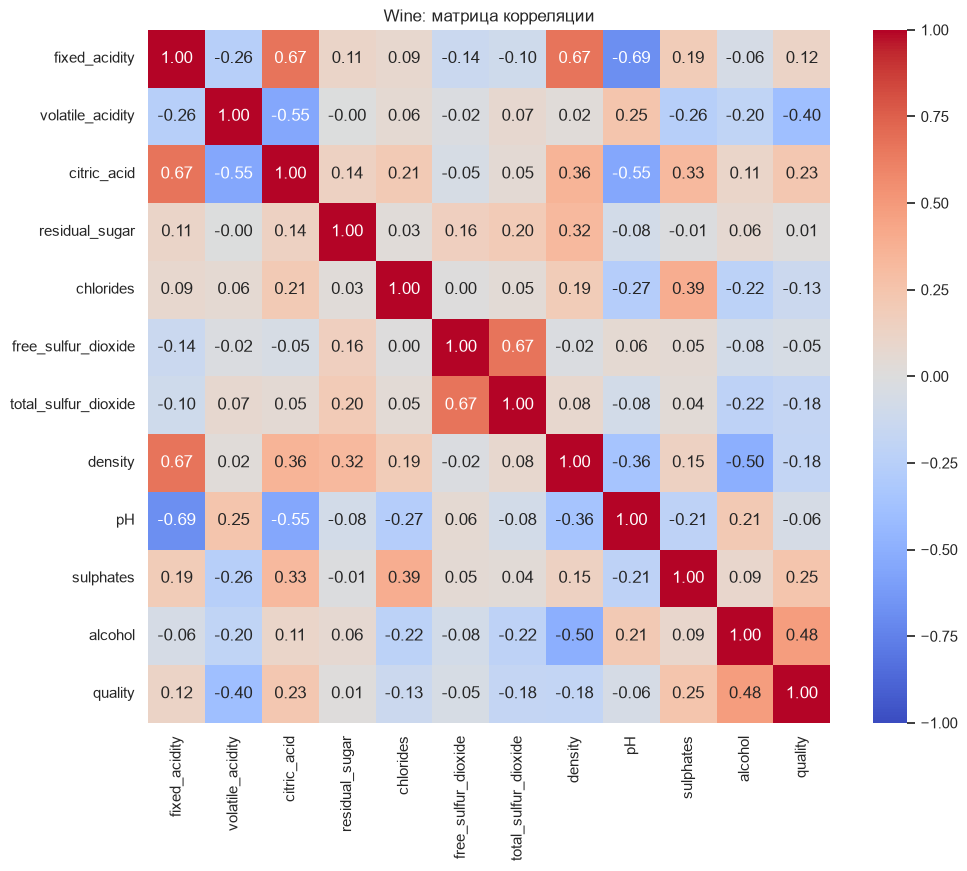

In [11]:
wine_corr = wine.corr()

plt.figure(figsize=(11, 9))
sns.heatmap(wine_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Wine: матрица корреляции")
plt.show()

In [12]:
# Пары с наибольшей по модулю корреляцией (верхний треугольник матрицы без диагонали)
pairs = wine_corr.where(np.triu(np.ones(wine_corr.shape, dtype=bool), k=1)).stack()
top_pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(5)
top_pairs

fixed_acidity        pH                     -0.686685
                     density                 0.670195
                     citric_acid             0.667437
free_sulfur_dioxide  total_sulfur_dioxide    0.667246
volatile_acidity     citric_acid            -0.551248
dtype: float64

Сильных зависимостей (|r| > 0.7) нет. Наиболее заметные связи (|r| ≈ 0.67–0.69):
`fixed_acidity` с `pH` (обратная), с `density` и с `citric_acid` (прямые), а также
`free_sulfur_dioxide` с `total_sulfur_dioxide`. С оценкой качества сильнее всего связаны
`alcohol` (r ≈ 0.48) и `volatile_acidity` (r ≈ −0.40).

Диаграммы рассеяния для четырёх пар с наиболее сильной линейной зависимостью:

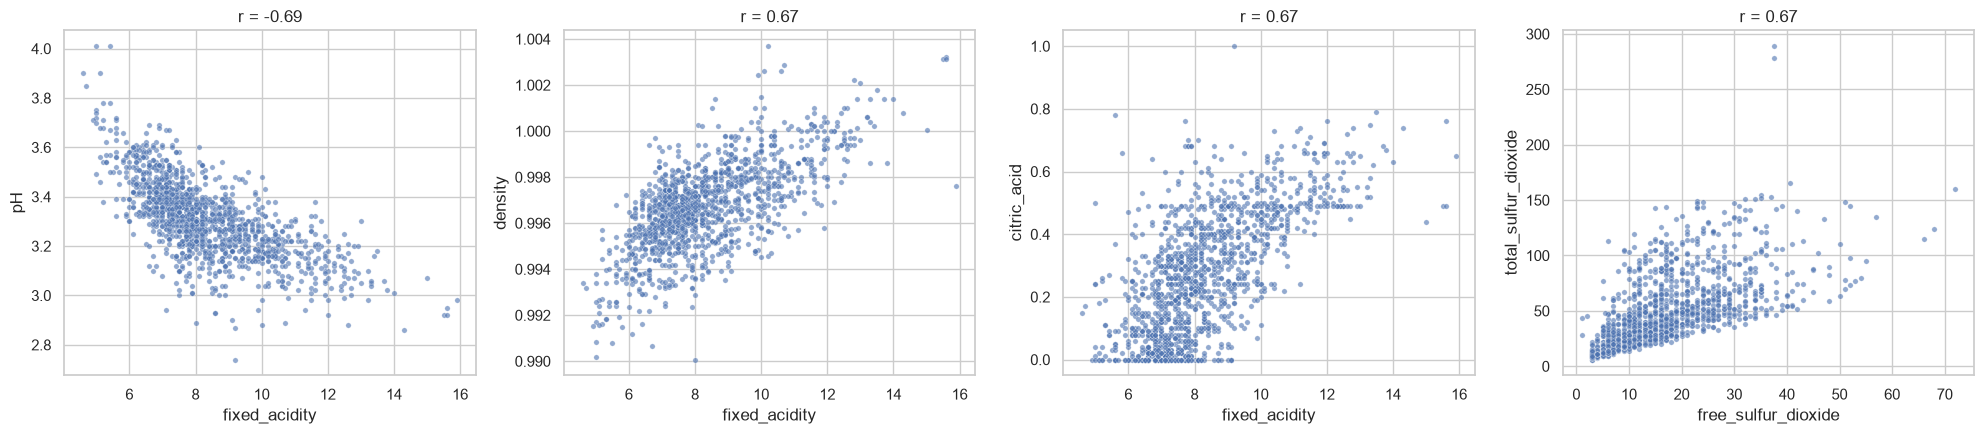

In [13]:
fig, axes = plt.subplots(1, 4, figsize=(20, 4.5))
for ax, (x, y) in zip(axes, top_pairs.index[:4]):
    sns.scatterplot(data=wine, x=x, y=y, s=15, alpha=0.6, ax=ax)
    ax.set_title(f"r = {wine_corr.loc[x, y]:.2f}")
fig.tight_layout()
plt.show()

Облака точек вытянуты вдоль прямой — связи линейные, но умеренные (разброс вокруг
линии большой).

## Вывод по набору Wine Quality

* Все 12 признаков числовые, пропусков нет; удалено 240 дубликатов (осталось 1359 строк).
* Большинство признаков скошены вправо; больше всего выбросов у `residual_sugar` и `chlorides`.
* Сильных корреляций нет, умеренные (|r| до 0.69) — между показателями кислотности,
  плотностью и между двумя показателями диоксида серы. Качество сильнее всего связано
  с содержанием алкоголя.

---
# Часть 2.2. Набор данных №2 — Adult (Census Income)

Данные переписи населения США: возраст, образование, семейное положение, профессия, пол
и т. д.; целевой признак `income` — доход больше или меньше $50 000 в год.

## 1. Первичный аудит и структура данных

Файл не содержит строки заголовка, значения разделены `", "`, а пропуски обозначены символом `?`.
Поэтому имена столбцов задаются вручную, `skipinitialspace=True` убирает пробелы перед
значениями, а `na_values="?"` превращает `?` в пропуски (NaN).

In [14]:
columns = ["age", "workclass", "fnlwgt", "education", "education_num", "marital_status",
           "occupation", "relationship", "race", "sex", "capital_gain", "capital_loss",
           "hours_per_week", "native_country", "income"]

adult = pd.read_csv(DATA_DIR / "adult.csv", header=None, names=columns,
                    skipinitialspace=True, na_values="?")

display(adult.head(10))
display(adult.tail(10))

,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
0,39,State-gov,77516,Bachelors,13,Never-married,Adm-clerical,Not-in-family,White,Male,2174,0,40,United-States,<=50K
1,50,Self-emp-not-inc,83311,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,13,United-States,<=50K
2,38,Private,215646,HS-grad,9,Divorced,Handlers-cleaners,Not-in-family,White,Male,0,0,40,United-States,<=50K
3,53,Private,234721,11th,7,Married-civ-spouse,Handlers-cleaners,Husband,Black,Male,0,0,40,United-States,<=50K
4,28,Private,338409,Bachelors,13,Married-civ-spouse,Prof-specialty,Wife,Black,Female,0,0,40,Cuba,<=50K
5,37,Private,284582,Masters,14,Married-civ-spouse,Exec-managerial,Wife,White,Female,0,0,40,United-States,<=50K
6,49,Private,160187,9th,5,Married-spouse-absent,Other-service,Not-in-family,Black,Female,0,0,16,Jamaica,<=50K
7,52,Self-emp-not-inc,209642,HS-grad,9,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,45,United-States,>50K
8,31,Private,45781,Masters,14,Never-married,Prof-specialty,Not-in-family,White,Female,14084,0,50,United-States,>50K
9,42,Private,159449,Bachelors,13,Married-civ-spouse,Exec-managerial,Husband,White,Male,5178,0,40,United-States,>50K


,age,workclass,fnlwgt,education,education_num,marital_status,occupation,relationship,race,sex,capital_gain,capital_loss,hours_per_week,native_country,income
32551,32,Private,34066,10th,6,Married-civ-spouse,Handlers-cleaners,Husband,Amer-Indian-Eskimo,Male,0,0,40,United-States,<=50K
32552,43,Private,84661,Assoc-voc,11,Married-civ-spouse,Sales,Husband,White,Male,0,0,45,United-States,<=50K
32553,32,Private,116138,Masters,14,Never-married,Tech-support,Not-in-family,Asian-Pac-Islander,Male,0,0,11,Taiwan,<=50K
32554,53,Private,321865,Masters,14,Married-civ-spouse,Exec-managerial,Husband,White,Male,0,0,40,United-States,>50K
32555,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32556,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32557,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32558,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K
32559,22,Private,201490,HS-grad,9,Never-married,Adm-clerical,Own-child,White,Male,0,0,20,United-States,<=50K
32560,52,Self-emp-inc,287927,HS-grad,9,Married-civ-spouse,Exec-managerial,Wife,White,Female,15024,0,40,United-States,>50K


In [15]:
print("Размерность (строк, столбцов):", adult.shape)
print()
adult.info()

Размерность (строк, столбцов): (32561, 15)

<class 'pandas.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32561 non-null  int64
 1   workclass       30725 non-null  str  
 2   fnlwgt          32561 non-null  int64
 3   education       32561 non-null  str  
 4   education_num   32561 non-null  int64
 5   marital_status  32561 non-null  str  
 6   occupation      30718 non-null  str  
 7   relationship    32561 non-null  str  
 8   race            32561 non-null  str  
 9   sex             32561 non-null  str  
 10  capital_gain    32561 non-null  int64
 11  capital_loss    32561 non-null  int64
 12  hours_per_week  32561 non-null  int64
 13  native_country  31978 non-null  str  
 14  income          32561 non-null  str  
dtypes: int64(6), str(9)
memory usage: 6.2 MB


6 столбцов целочисленные (`int64`), 9 — строковые; это соответствует содержимому:
строковые столбцы — категориальные признаки. В `workclass`, `occupation` и `native_country`
непустых значений меньше, чем строк, — там есть пропуски.

## 2. Статистический анализ и очистка данных

In [16]:
adult.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32561.0,38.581647,13.640433,17.0,28.0,37.0,48.0,90.0
fnlwgt,32561.0,189778.366512,105549.977697,12285.0,117827.0,178356.0,237051.0,1484705.0
education_num,32561.0,10.080679,2.572720,1.0,9.0,10.0,12.0,16.0
capital_gain,32561.0,1077.648844,7385.292085,0.0,0.0,0.0,0.0,99999.0
capital_loss,32561.0,87.303830,402.960219,0.0,0.0,0.0,0.0,4356.0
hours_per_week,32561.0,40.437456,12.347429,1.0,40.0,40.0,45.0,99.0


In [17]:
# Категориальные признаки: число уникальных значений и мода (top) с её частотой (freq)
adult.describe(exclude="number").T

,count,unique,top,freq
workclass,30725,8,Private,22696
education,32561,16,HS-grad,10501
marital_status,32561,7,Married-civ-spouse,14976
occupation,30718,14,Prof-specialty,4140
relationship,32561,6,Husband,13193
race,32561,5,White,27816
sex,32561,2,Male,21790
native_country,31978,41,United-States,29170
income,32561,2,<=50K,24720


Средний возраст ≈ 38.6 года (медиана 37), типичная рабочая неделя — 40 часов.
У `capital_gain` и `capital_loss` медиана и даже 75-й перцентиль равны нулю, а максимум
`capital_gain` = 99999 — признак очень сильной асимметрии. В категориальных признаках часто
доминирует одно значение: `native_country` — United-States, `race` — White, `workclass` — Private.
Доход >50K имеют около 24 % людей.

In [18]:
missing = adult.isna().sum()
print("Пропуски по столбцам:")
print(missing[missing > 0].to_string())
print(f"\nСтрок хотя бы с одним пропуском: {adult.isna().any(axis=1).sum()}")

Пропуски по столбцам:
workclass         1836
occupation        1843
native_country     583

Строк хотя бы с одним пропуском: 2399


Пропуски есть только в трёх категориальных столбцах (≈ 1.8–5.7 % значений). Для
категориальных признаков среднее и медиана неприменимы, поэтому пропуски **заполняются модой**
(самым частым значением столбца).

In [19]:
for col in ["workclass", "occupation", "native_country"]:
    mode = adult[col].mode()[0]
    adult[col] = adult[col].fillna(mode)
    print(f"{col}: пропуски заполнены значением '{mode}'")

print("\nПропусков после обработки:", int(adult.isna().sum().sum()))

workclass: пропуски заполнены значением 'Private'
occupation: пропуски заполнены значением 'Prof-specialty'
native_country: пропуски заполнены значением 'United-States'

Пропусков после обработки: 0


In [20]:
print("Дубликатов:", adult.duplicated().sum())
adult = adult.drop_duplicates().reset_index(drop=True)
print("Размерность после удаления дубликатов:", adult.shape)

Дубликатов: 24
Размерность после удаления дубликатов: (32537, 15)


Найдено и удалено 24 повторяющиеся строки.

## 3. Визуальный анализ распределений и поиск аномалий

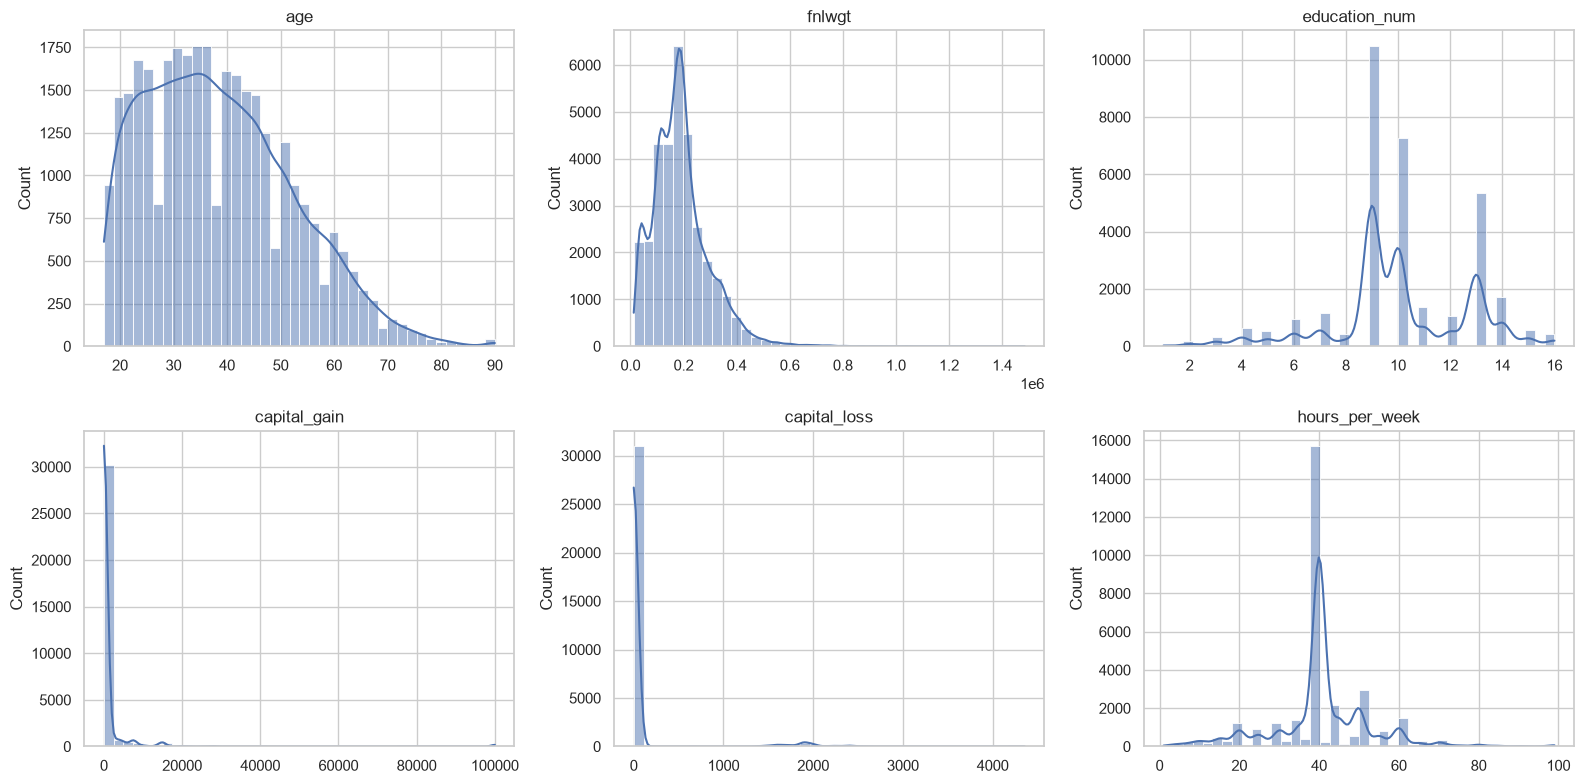

In [21]:
num_cols = adult.select_dtypes("number").columns

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
for ax, col in zip(axes.flat, num_cols):
    sns.histplot(adult[col], bins=40, kde=True, ax=ax)
    ax.set_title(col)
    ax.set_xlabel("")
fig.tight_layout()
plt.show()

`age` и `fnlwgt` скошены вправо; `education_num` дискретен с пиками на 9 (школа) и 13
(бакалавриат); у `hours_per_week` резкий пик на 40 часах. `capital_gain` и `capital_loss`
почти всегда равны нулю, а ненулевые значения редки и разбросаны далеко вправо.

**Один признак — три типа графиков** (возраст `age`):

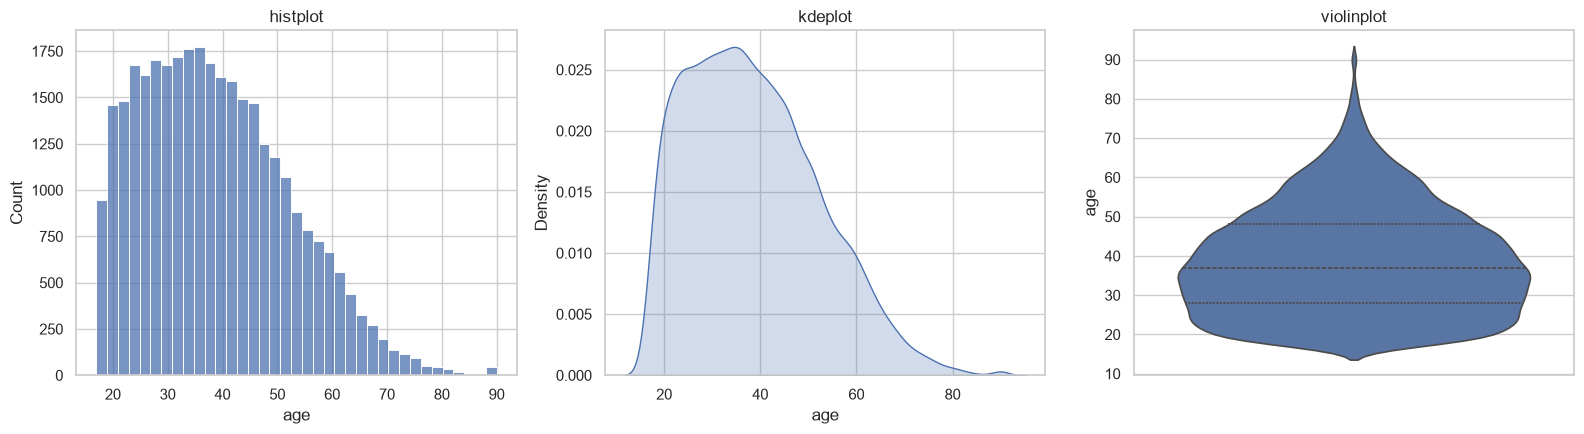

In [22]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4.5))
sns.histplot(adult["age"], bins=37, ax=axes[0])
axes[0].set_title("histplot")
sns.kdeplot(adult["age"], fill=True, ax=axes[1])
axes[1].set_title("kdeplot")
sns.violinplot(y=adult["age"], inner="quartile", ax=axes[2])
axes[2].set_title("violinplot")
fig.tight_layout()
plt.show()

Все три графика показывают правоскошенное распределение возраста с основной массой
людей 20–50 лет. На гистограмме видна «зубчатость» (возраст — целые числа), график плотности
её сглаживает, скрипичная диаграмма показывает медиану (37 лет) и квартили.

**Диаграммы размаха (boxplot)** для поиска выбросов:

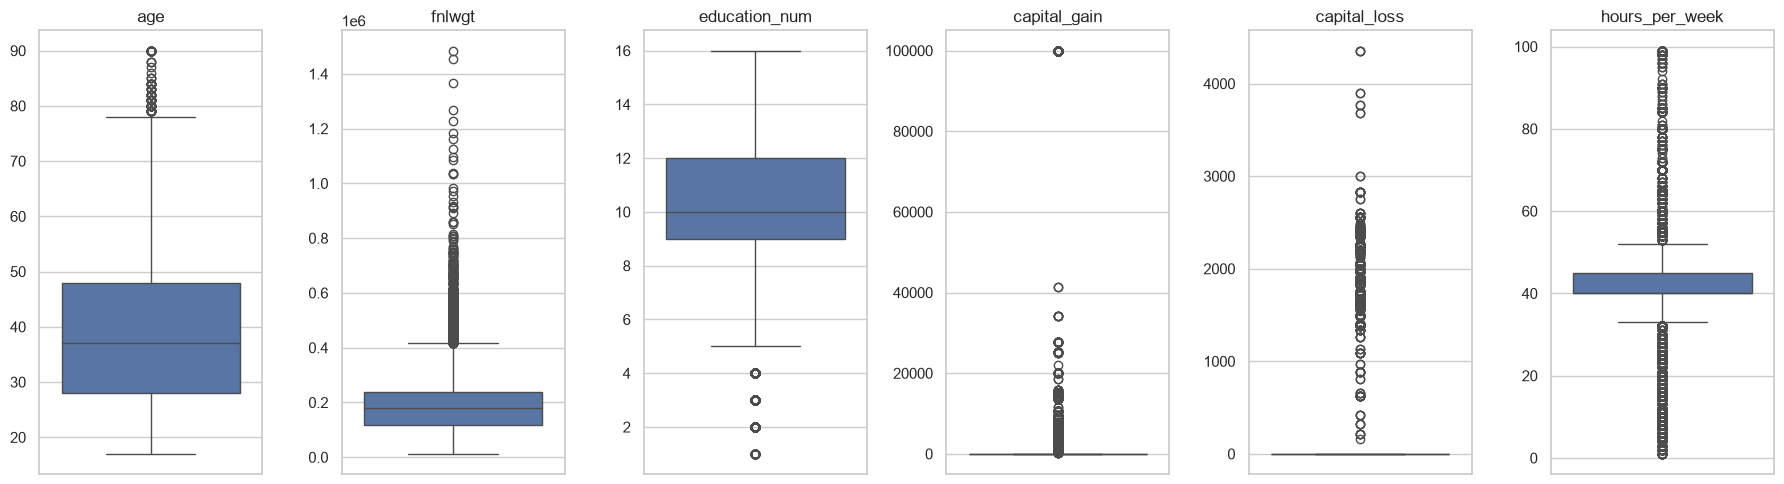

,выбросов,"доля, %"
hours_per_week,9002,27.67
capital_gain,2712,8.34
capital_loss,1519,4.67
education_num,1193,3.67
fnlwgt,993,3.05
age,142,0.44


In [23]:
fig, axes = plt.subplots(1, 6, figsize=(18, 5))
for ax, col in zip(axes, num_cols):
    sns.boxplot(y=adult[col], ax=ax)
    ax.set_title(col)
    ax.set_ylabel("")
fig.tight_layout()
plt.show()

iqr_outliers(adult[num_cols])

Формально выбросов много, но их нужно интерпретировать:
* `hours_per_week` (≈ 28 %) — межквартильный размах очень узкий (40–45 часов), поэтому
  любая неполная или удлинённая неделя попадает в выбросы, хотя это нормальные значения;
* `capital_gain`, `capital_loss` — IQR равен нулю, поэтому выбросом считается любое ненулевое
  значение; явная аномалия — значение 99999 у `capital_gain`, похожее на искусственный предел;
* у `age` выбросы — люди старше 78 лет (< 0.5 %), значения редкие, но корректные.

## 4. Корреляционный анализ и зависимости

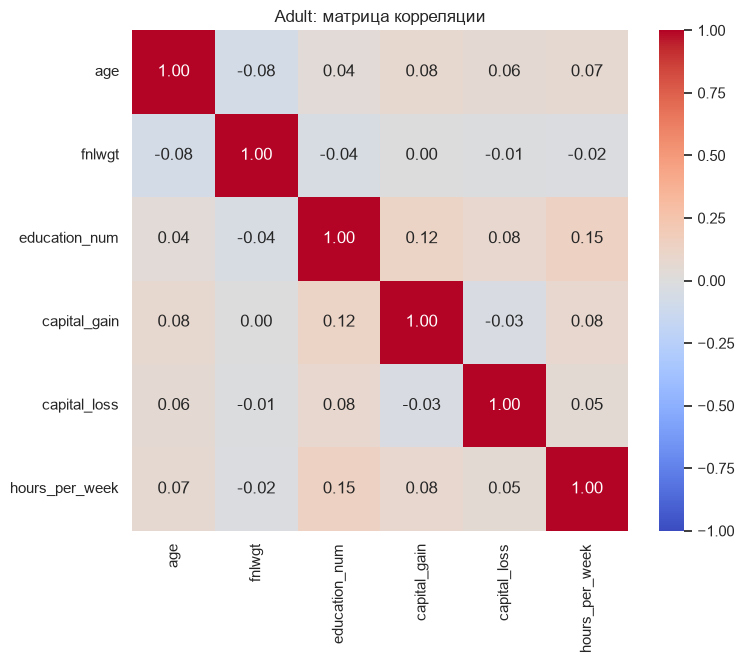

In [24]:
adult_corr = adult[num_cols].corr()

plt.figure(figsize=(8, 6.5))
sns.heatmap(adult_corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Adult: матрица корреляции")
plt.show()

In [25]:
pairs = adult_corr.where(np.triu(np.ones(adult_corr.shape, dtype=bool), k=1)).stack()
top_pairs = pairs.reindex(pairs.abs().sort_values(ascending=False).index).head(5)
top_pairs

education_num  hours_per_week    0.148422
               capital_gain      0.122664
               capital_loss      0.079892
capital_gain   hours_per_week    0.078408
age            capital_gain      0.077676
dtype: float64

Линейные связи между числовыми признаками очень слабые: максимальный коэффициент
≈ 0.15 (`education_num` и `hours_per_week`), остальные по модулю не превышают 0.12.

Парный график для признаков из наиболее связанных пар (случайная выборка 3000 строк,
чтобы точки не сливались):

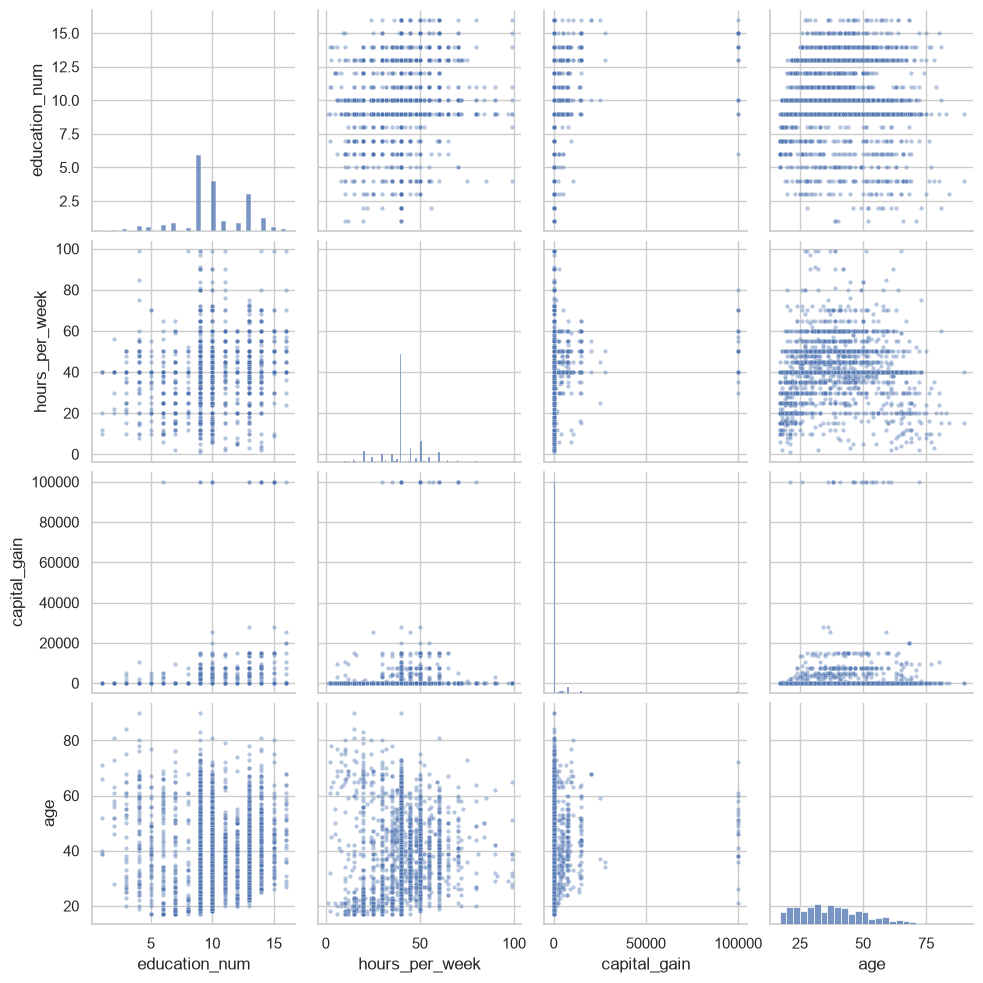

In [26]:
sample = adult.sample(3000, random_state=42)
sns.pairplot(sample, vars=["education_num", "hours_per_week", "capital_gain", "age"],
             plot_kws={"s": 10, "alpha": 0.4})
plt.show()

Облака точек не вытянуты вдоль прямых — линейной зависимости между признаками нет.
Видны дискретность `education_num`, «полоса» на 40 часах у `hours_per_week` и то, что
`capital_gain` почти всегда равен нулю.

## Вывод по набору Adult

* 32561 строка, 6 числовых и 9 категориальных признаков; пропуски (символ `?`) в трёх
  категориальных столбцах заполнены модой, удалено 24 дубликата.
* Числовые признаки неоднородны: правоскошенный возраст, пик рабочей недели на 40 часах,
  почти нулевые `capital_gain` / `capital_loss`.
* По правилу IQR выбросов много, но в основном это следствие узкого межквартильного
  размаха; реальная аномалия — значение 99999 в `capital_gain`.
* Сильных корреляций между числовыми признаками нет (|r| ≤ 0.15).

---
# Часть 3. Дополнительное задание — Streamlit

Ключевые элементы анализа набора Adult перенесены в веб-приложение
[`app_streamlit.py`](app_streamlit.py): выбор способа обработки пропусков и удаления дубликатов,
фильтры (возраст, пол, доход, образование), динамическая таблица данных, выбор признака и типа
графика распределения, таблица выбросов, матрица корреляции и диаграмма рассеяния.

Запуск:

```bat
conda activate lab1_terminal
streamlit run app_streamlit.py
```